## Setup and preprocessing — FFF, fresh raw load (3-DAG-split notebook)

In [2]:
# Block 1 — Fresh raw load, same preprocessing as combined notebook, repeated independently

import pandas as pd
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from dowhy import CausalModel
from econml.dml import CausalForestDML

OUTPUT_DIR = r"C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PATH = r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\FFF.csv"
df = pd.read_csv(DATA_PATH)

df_sel = df.copy()

df_sel['imd_band'] = df_sel['imd_band'].replace('10-20', '10-20%')
imd_mode = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(imd_mode)

final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df_sel['final_result'] = df_sel['final_result'].map(final_result_map)

highest_education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
df_sel['highest_education'] = df_sel['highest_education'].map(highest_education_map)

imd_band_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
df_sel['imd_band'] = df_sel['imd_band'].map(imd_band_map)

age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

df_sel['gender'] = df_sel['gender'].map({'F': 0, 'M': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

le = LabelEncoder()
df_sel['region'] = le.fit_transform(df_sel['region'])

assessment_cols = [f'ass_{i}_score' for i in range(1, 13)]
for col in assessment_cols:
    df_sel[col] = df_sel[col].fillna(-1)
    df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')

click_cols_all = ['clicks_dataplus', 'clicks_dualpane', 'clicks_folder', 'clicks_forumng',
                   'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate',
                   'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page',
                   'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource',
                   'clicks_subpage', 'clicks_url']
for col in click_cols_all:
    df_sel[col] = df_sel[col].fillna(0)

print(df_sel.shape)
print(df_sel[['gender', 'region', 'final_result']].head())

(7762, 55)
   gender  region  final_result
0       0       7             3
1       1      10             2
2       1       9             2
3       1      11             0
4       1       8             0


## DAG1 — Demographics vs final_result — build graph, derive adjustment sets, run ATE + refutation

In [5]:
# Block 2 — DAG1 edges, treatments, adjustment sets

dag1_edges = [
    ('gender', 'region'),
    ('gender', 'studied_credits'),
    ('highest_education', 'region'),
    ('imd_band', 'region'),
    ('disability', 'region'),
    ('region', 'final_result'),
    ('highest_education', 'final_result'),
    ('imd_band', 'final_result'),
    ('age_band', 'final_result'),
    ('num_of_prev_attempts', 'studied_credits'),
    ('num_of_prev_attempts', 'final_result'),
    ('studied_credits', 'final_result'),
    ('disability', 'final_result'),
]
dag1_undirected = [('highest_education', 'imd_band'), ('highest_education', 'age_band'),
                    ('highest_education', 'disability'), ('imd_band', 'disability')]

G1 = nx.DiGraph()
G1.add_edges_from(dag1_edges)

dag1_treatments = [n for n in G1.nodes() if n != 'final_result' and nx.has_path(G1, n, 'final_result')]
print("DAG1 treatments:", dag1_treatments)

dag1_adjustment_sets = {t: list(G1.predecessors(t)) for t in dag1_treatments}
for t, adj in dag1_adjustment_sets.items():
    print(t, "->", adj)

DAG1 treatments: ['gender', 'region', 'studied_credits', 'highest_education', 'imd_band', 'disability', 'age_band', 'num_of_prev_attempts']
gender -> []
region -> ['gender', 'highest_education', 'imd_band', 'disability']
studied_credits -> ['gender', 'num_of_prev_attempts']
highest_education -> []
imd_band -> []
disability -> []
age_band -> []
num_of_prev_attempts -> []


## DAG1 — ATE loop with refutation

In [8]:
# Block 3 — DAG1 ATE loop with refutation

dag1_results = []
dag1_refutation = []

for treatment in dag1_treatments:
    common_causes = dag1_adjustment_sets[treatment]

    model = CausalModel(
        data=df_sel,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    dag1_results.append({
        'DAG': 1, 'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    placebo_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute"
    )
    random_cause_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause"
    )

    dag1_refutation.append({
        'treatment': treatment, 'original_ATE': ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_new_effect': random_cause_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - ate)
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

dag1_results_df = pd.DataFrame(dag1_results)
dag1_refutation_df = pd.DataFrame(dag1_refutation)
dag1_results_df

gender: ATE=-0.011, CI=[-0.068, 0.046], significant=False
region: ATE=-0.001, CI=[-0.007, 0.005], significant=False
studied_credits: ATE=-0.004, CI=[-0.004, -0.003], significant=True
highest_education: ATE=0.227, CI=[0.197, 0.256], significant=True
imd_band: ATE=0.045, CI=[0.037, 0.053], significant=True
disability: ATE=-0.280, CI=[-0.355, -0.205], significant=True
age_band: ATE=0.098, CI=[0.049, 0.147], significant=True
num_of_prev_attempts: ATE=-0.160, CI=[-0.202, -0.118], significant=True


,DAG,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,1,gender,[],-0.011367,-0.068371,0.045636,False
1,1,region,"[gender, highest_education, imd_band, disability]",-0.000699,-0.006607,0.005210,False
2,1,studied_credits,"[gender, num_of_prev_attempts]",-0.003503,-0.004052,-0.002954,True
3,1,highest_education,[],0.226550,0.197110,0.255990,True
4,1,imd_band,[],0.045072,0.037259,0.052884,True
5,1,disability,[],-0.280035,-0.354925,-0.205145,True
6,1,age_band,[],0.097597,0.048601,0.146594,True
7,1,num_of_prev_attempts,[],-0.160003,-0.202213,-0.117793,True


In [10]:
dag1_refutation_df

,treatment,original_ATE,placebo_new_effect,random_cause_new_effect,random_cause_diff
0,gender,-0.011367,0.003766,-0.011395,2.769626e-05
1,region,-0.000699,0.000450,-0.000697,2.036627e-06
2,studied_credits,-0.003503,0.000007,-0.003504,3.081088e-07
3,highest_education,0.226550,0.000711,0.226531,1.894271e-05
4,imd_band,0.045072,0.000555,0.045077,4.805926e-06
5,disability,-0.280035,-0.007718,-0.280017,1.752556e-05
6,age_band,0.097597,-0.002722,0.097597,5.644671e-08
7,num_of_prev_attempts,-0.160003,0.000992,-0.160021,1.793770e-05


## DAG2 — Assessments vs final_result — build graph, derive adjustment sets, run ATE + refutation

In [13]:
# Block 4 — DAG2 edges, treatments, adjustment sets

dag2_edges = [
    ('ass_1_score', 'ass_2_score'), ('ass_1_score', 'ass_3_score'), ('ass_1_score', 'ass_4_score'),
    ('ass_1_score', 'ass_6_score'), ('ass_1_score', 'ass_7_score'), ('ass_1_score', 'final_result'),
    ('ass_2_score', 'ass_3_score'), ('ass_2_score', 'ass_4_score'), ('ass_2_score', 'ass_5_score'),
    ('ass_2_score', 'ass_6_score'), ('ass_2_score', 'ass_8_score'), ('ass_2_score', 'final_result'),
    ('ass_3_score', 'ass_4_score'), ('ass_3_score', 'ass_5_score'), ('ass_3_score', 'ass_6_score'),
    ('ass_3_score', 'ass_7_score'), ('ass_3_score', 'ass_8_score'), ('ass_3_score', 'ass_9_score'),
    ('ass_3_score', 'final_result'),
    ('ass_4_score', 'ass_5_score'), ('ass_4_score', 'ass_6_score'), ('ass_4_score', 'ass_7_score'),
    ('ass_4_score', 'ass_8_score'), ('ass_4_score', 'ass_9_score'), ('ass_4_score', 'ass_10_score'),
    ('ass_4_score', 'ass_11_score'), ('ass_4_score', 'ass_12_score'), ('ass_4_score', 'final_result'),
    ('ass_5_score', 'ass_10_score'), ('ass_5_score', 'final_result'),
    ('ass_6_score', 'ass_7_score'), ('ass_6_score', 'ass_8_score'), ('ass_6_score', 'ass_9_score'),
    ('ass_6_score', 'ass_10_score'), ('ass_6_score', 'ass_11_score'), ('ass_6_score', 'ass_12_score'),
    ('ass_7_score', 'ass_8_score'), ('ass_7_score', 'ass_9_score'), ('ass_7_score', 'ass_10_score'),
    ('ass_7_score', 'ass_11_score'), ('ass_7_score', 'ass_12_score'), ('ass_7_score', 'final_result'),
    ('ass_8_score', 'ass_9_score'), ('ass_8_score', 'ass_10_score'), ('ass_8_score', 'ass_11_score'),
    ('ass_8_score', 'ass_12_score'), ('ass_8_score', 'final_result'),
    ('ass_9_score', 'ass_10_score'), ('ass_9_score', 'ass_11_score'), ('ass_9_score', 'ass_12_score'),
    ('ass_9_score', 'final_result'),
    ('ass_10_score', 'ass_11_score'), ('ass_10_score', 'ass_12_score'), ('ass_10_score', 'final_result'),
    ('ass_11_score', 'ass_12_score'), ('ass_11_score', 'final_result'),
    ('ass_12_score', 'final_result'),
]

G2 = nx.DiGraph()
G2.add_edges_from(dag2_edges)

dag2_treatments = [n for n in G2.nodes() if n != 'final_result' and nx.has_path(G2, n, 'final_result')]
print("DAG2 treatments:", dag2_treatments)
print("Count:", len(dag2_treatments))

dag2_adjustment_sets = {t: list(G2.predecessors(t)) for t in dag2_treatments}
for t, adj in dag2_adjustment_sets.items():
    print(t, "->", adj)

DAG2 treatments: ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_6_score', 'ass_7_score', 'ass_5_score', 'ass_8_score', 'ass_9_score', 'ass_10_score', 'ass_11_score', 'ass_12_score']
Count: 12
ass_1_score -> []
ass_2_score -> ['ass_1_score']
ass_3_score -> ['ass_1_score', 'ass_2_score']
ass_4_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score']
ass_6_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score']
ass_7_score -> ['ass_1_score', 'ass_3_score', 'ass_4_score', 'ass_6_score']
ass_5_score -> ['ass_2_score', 'ass_3_score', 'ass_4_score']
ass_8_score -> ['ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_6_score', 'ass_7_score']
ass_9_score -> ['ass_3_score', 'ass_4_score', 'ass_6_score', 'ass_7_score', 'ass_8_score']
ass_10_score -> ['ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score']
ass_11_score -> ['ass_4_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'ass_10_score']
ass_12_score -> ['ass_4

## DAG2 — ATE loop with refutation

In [16]:
# Block 5 — DAG2 ATE loop with refutation

dag2_results = []
dag2_refutation = []

for treatment in dag2_treatments:
    common_causes = dag2_adjustment_sets[treatment]

    model = CausalModel(
        data=df_sel,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    dag2_results.append({
        'DAG': 2, 'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    placebo_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute"
    )
    random_cause_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause"
    )

    dag2_refutation.append({
        'treatment': treatment, 'original_ATE': ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_new_effect': random_cause_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - ate)
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

dag2_results_df = pd.DataFrame(dag2_results)
dag2_refutation_df = pd.DataFrame(dag2_refutation)
dag2_results_df

ass_1_score: ATE=0.471, CI=[0.454, 0.488], significant=True
ass_2_score: ATE=0.555, CI=[0.530, 0.581], significant=True
ass_3_score: ATE=0.685, CI=[0.659, 0.710], significant=True
ass_4_score: ATE=0.635, CI=[0.608, 0.662], significant=True
ass_6_score: ATE=0.166, CI=[0.145, 0.187], significant=True
ass_7_score: ATE=0.209, CI=[0.183, 0.235], significant=True
ass_5_score: ATE=0.240, CI=[0.199, 0.282], significant=True
ass_8_score: ATE=0.369, CI=[0.341, 0.397], significant=True
ass_9_score: ATE=0.342, CI=[0.314, 0.371], significant=True
ass_10_score: ATE=0.308, CI=[0.278, 0.338], significant=True
ass_11_score: ATE=0.358, CI=[0.326, 0.390], significant=True
ass_12_score: ATE=0.213, CI=[0.181, 0.245], significant=True


,DAG,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,2,ass_1_score,[],0.470782,0.454024,0.487541,True
1,2,ass_2_score,[ass_1_score],0.555275,0.529564,0.580986,True
2,2,ass_3_score,"[ass_1_score, ass_2_score]",0.684788,0.659326,0.710251,True
3,2,ass_4_score,"[ass_1_score, ass_2_score, ass_3_score]",0.634806,0.607828,0.661784,True
4,2,ass_6_score,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.165972,0.144584,0.187360,True
5,2,ass_7_score,"[ass_1_score, ass_3_score, ass_4_score, ass_6_...",0.208629,0.182677,0.234580,True
6,2,ass_5_score,"[ass_2_score, ass_3_score, ass_4_score]",0.240142,0.198518,0.281766,True
7,2,ass_8_score,"[ass_2_score, ass_3_score, ass_4_score, ass_6_...",0.369222,0.340974,0.397470,True
8,2,ass_9_score,"[ass_3_score, ass_4_score, ass_6_score, ass_7_...",0.342399,0.313975,0.370824,True
9,2,ass_10_score,"[ass_4_score, ass_5_score, ass_6_score, ass_7_...",0.308195,0.278376,0.338014,True


In [18]:
dag2_refutation_df

,treatment,original_ATE,placebo_new_effect,random_cause_new_effect,random_cause_diff
0,ass_1_score,0.470782,-0.000225,0.470791,8.479036e-06
1,ass_2_score,0.555275,-0.000901,0.555291,1.608906e-05
2,ass_3_score,0.684788,0.001695,0.684774,1.441976e-05
3,ass_4_score,0.634806,-0.000835,0.634789,1.709322e-05
4,ass_6_score,0.165972,0.000369,0.165957,1.472252e-05
5,ass_7_score,0.208629,-0.000210,0.208634,5.399016e-06
6,ass_5_score,0.240142,-0.001658,0.240141,9.443585e-07
7,ass_8_score,0.369222,-0.001019,0.369219,2.930205e-06
8,ass_9_score,0.342399,-0.001112,0.342377,2.242814e-05
9,ass_10_score,0.308195,-0.000126,0.308217,2.198919e-05


## DAG3 — Individual clicks vs final_result — fresh pull from raw df, re-bin, build graph, run ATE + refutation

In [21]:
# Block 6 — DAG3 fresh click pull, re-bin (excluding clicks_repeatactivity, matching combined-DAG exclusion)

click_cols_dag3 = ['clicks_dataplus', 'clicks_dualpane', 'clicks_folder', 'clicks_forumng',
                    'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate',
                    'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page',
                    'clicks_questionnaire', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']

df_dag3 = df_sel[click_cols_dag3 + ['final_result']].copy()

for col in click_cols_dag3:
    try:
        df_dag3[col] = pd.qcut(df_dag3[col], q=4, labels=False, duplicates='drop')
    except ValueError as e:
        print(f"{col}: binning issue -> {e}")

for col in click_cols_dag3:
    print(col, df_dag3[col].nunique(), "bins")

clicks_dataplus 2 bins
clicks_dualpane 2 bins
clicks_folder 1 bins
clicks_forumng 4 bins
clicks_glossary 1 bins
clicks_homepage 4 bins
clicks_htmlactivity 1 bins
clicks_oucollaborate 2 bins
clicks_oucontent 4 bins
clicks_ouelluminate 1 bins
clicks_ouwiki 3 bins
clicks_page 4 bins
clicks_questionnaire 2 bins
clicks_quiz 4 bins
clicks_resource 4 bins
clicks_subpage 4 bins
clicks_url 4 bins


## DAG3 — drop 1-bin-collapsed columns, build graph, derive adjustment sets, run ATE + refutation

In [24]:
# Block 7 — Drop collapsed columns, DAG3 edges, treatments, adjustment sets

collapsed_cols = ['clicks_folder', 'clicks_glossary', 'clicks_htmlactivity', 'clicks_ouelluminate']
df_dag3 = df_dag3.drop(columns=collapsed_cols)

dag3_edges = [
    ('clicks_oucontent', 'clicks_dataplus'),
    ('clicks_page', 'clicks_dataplus'),
    ('clicks_questionnaire', 'clicks_dataplus'),
    ('clicks_url', 'clicks_dataplus'),
    ('clicks_dataplus', 'final_result'),
    ('clicks_dualpane', 'clicks_ouwiki'),
    ('clicks_dualpane', 'clicks_page'),
    ('clicks_dualpane', 'clicks_resource'),
    ('clicks_forumng', 'clicks_homepage'),
    ('clicks_oucollaborate', 'clicks_forumng'),
    ('clicks_oucontent', 'clicks_forumng'),
    ('clicks_ouwiki', 'clicks_forumng'),
    ('clicks_page', 'clicks_forumng'),
    ('clicks_quiz', 'clicks_forumng'),
    ('clicks_forumng', 'clicks_resource'),
    ('clicks_subpage', 'clicks_forumng'),
    ('clicks_url', 'clicks_forumng'),
    ('clicks_forumng', 'final_result'),
    ('clicks_oucontent', 'clicks_homepage'),
    ('clicks_ouwiki', 'clicks_homepage'),
    ('clicks_quiz', 'clicks_homepage'),
    ('clicks_resource', 'clicks_homepage'),
    ('clicks_subpage', 'clicks_homepage'),
    ('clicks_url', 'clicks_homepage'),
    ('clicks_oucollaborate', 'clicks_resource'),
    ('clicks_ouwiki', 'clicks_oucontent'),
    ('clicks_questionnaire', 'clicks_oucontent'),
    ('clicks_quiz', 'clicks_oucontent'),
    ('clicks_oucontent', 'clicks_resource'),
    ('clicks_subpage', 'clicks_oucontent'),
    ('clicks_url', 'clicks_oucontent'),
    ('clicks_oucontent', 'final_result'),
    ('clicks_questionnaire', 'clicks_ouwiki'),
    ('clicks_quiz', 'clicks_ouwiki'),
    ('clicks_ouwiki', 'clicks_resource'),
    ('clicks_url', 'clicks_ouwiki'),
    ('clicks_ouwiki', 'final_result'),
    ('clicks_questionnaire', 'clicks_page'),
    ('clicks_quiz', 'clicks_page'),
    ('clicks_page', 'clicks_resource'),
    ('clicks_url', 'clicks_page'),
    ('clicks_page', 'final_result'),
    ('clicks_quiz', 'clicks_resource'),
    ('clicks_quiz', 'final_result'),
    ('clicks_subpage', 'clicks_resource'),
    ('clicks_url', 'clicks_resource'),
    ('clicks_resource', 'final_result'),
]
dag3_undirected = [('clicks_dualpane', 'clicks_questionnaire'), ('clicks_ouwiki', 'clicks_page'),
                    ('clicks_quiz', 'clicks_subpage'), ('clicks_subpage', 'clicks_url')]

G3 = nx.DiGraph()
G3.add_edges_from(dag3_edges)

dag3_treatments = [n for n in G3.nodes() if n != 'final_result' and nx.has_path(G3, n, 'final_result')]
print("DAG3 treatments:", dag3_treatments)
print("Count:", len(dag3_treatments))

dag3_adjustment_sets = {t: list(G3.predecessors(t)) for t in dag3_treatments}
for t, adj in dag3_adjustment_sets.items():
    print(t, "->", adj)

DAG3 treatments: ['clicks_oucontent', 'clicks_dataplus', 'clicks_page', 'clicks_questionnaire', 'clicks_url', 'clicks_dualpane', 'clicks_ouwiki', 'clicks_resource', 'clicks_forumng', 'clicks_oucollaborate', 'clicks_quiz', 'clicks_subpage']
Count: 12
clicks_oucontent -> ['clicks_ouwiki', 'clicks_questionnaire', 'clicks_quiz', 'clicks_subpage', 'clicks_url']
clicks_dataplus -> ['clicks_oucontent', 'clicks_page', 'clicks_questionnaire', 'clicks_url']
clicks_page -> ['clicks_dualpane', 'clicks_questionnaire', 'clicks_quiz', 'clicks_url']
clicks_questionnaire -> []
clicks_url -> []
clicks_dualpane -> []
clicks_ouwiki -> ['clicks_dualpane', 'clicks_questionnaire', 'clicks_quiz', 'clicks_url']
clicks_resource -> ['clicks_dualpane', 'clicks_forumng', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_page', 'clicks_quiz', 'clicks_subpage', 'clicks_url']
clicks_forumng -> ['clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_page', 'clicks_quiz', 'clicks_subpag

## DAG3 — ATE loop with refutation

In [29]:
# Block 8 — DAG3 ATE loop with refutation

dag3_results = []
dag3_refutation = []

for treatment in dag3_treatments:
    common_causes = dag3_adjustment_sets[treatment]

    model = CausalModel(
        data=df_dag3,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    dag3_results.append({
        'DAG': 3, 'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    placebo_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute"
    )
    random_cause_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause"
    )

    dag3_refutation.append({
        'treatment': treatment, 'original_ATE': ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_new_effect': random_cause_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - ate)
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

dag3_results_df = pd.DataFrame(dag3_results)
dag3_refutation_df = pd.DataFrame(dag3_refutation)
dag3_results_df

clicks_oucontent: ATE=0.301, CI=[0.270, 0.332], significant=True
clicks_dataplus: ATE=0.380, CI=[0.330, 0.430], significant=True
clicks_page: ATE=-0.034, CI=[-0.052, -0.015], significant=True
clicks_questionnaire: ATE=1.140, CI=[1.095, 1.184], significant=True
clicks_url: ATE=0.581, CI=[0.566, 0.596], significant=True
clicks_dualpane: ATE=0.907, CI=[0.857, 0.957], significant=True
clicks_ouwiki: ATE=-0.081, CI=[-0.106, -0.055], significant=True
clicks_resource: ATE=0.052, CI=[0.030, 0.074], significant=True
clicks_forumng: ATE=0.010, CI=[-0.012, 0.032], significant=False
clicks_oucollaborate: ATE=0.760, CI=[0.711, 0.809], significant=True
clicks_quiz: ATE=0.659, CI=[0.646, 0.672], significant=True
clicks_subpage: ATE=0.631, CI=[0.617, 0.645], significant=True


,DAG,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,3,clicks_oucontent,"[clicks_ouwiki, clicks_questionnaire, clicks_q...",0.300931,0.270280,0.331583,True
1,3,clicks_dataplus,"[clicks_oucontent, clicks_page, clicks_questio...",0.380065,0.330365,0.429766,True
2,3,clicks_page,"[clicks_dualpane, clicks_questionnaire, clicks...",-0.033714,-0.052474,-0.014954,True
3,3,clicks_questionnaire,[],1.139702,1.095011,1.184394,True
4,3,clicks_url,[],0.581142,0.566254,0.596030,True
5,3,clicks_dualpane,[],0.907205,0.857346,0.957065,True
6,3,clicks_ouwiki,"[clicks_dualpane, clicks_questionnaire, clicks...",-0.080668,-0.106384,-0.054952,True
7,3,clicks_resource,"[clicks_dualpane, clicks_forumng, clicks_oucol...",0.051843,0.030012,0.073674,True
8,3,clicks_forumng,"[clicks_oucollaborate, clicks_oucontent, click...",0.009719,-0.012365,0.031804,False
9,3,clicks_oucollaborate,[],0.760099,0.711204,0.808994,True


In [31]:
dag3_refutation_df

,treatment,original_ATE,placebo_new_effect,random_cause_new_effect,random_cause_diff
0,clicks_oucontent,0.300931,-0.000030,0.300940,8.910866e-06
1,clicks_dataplus,0.380065,0.000377,0.380035,3.043937e-05
2,clicks_page,-0.033714,-0.000664,-0.033720,5.762481e-06
3,clicks_questionnaire,1.139702,-0.001007,1.139679,2.303280e-05
4,clicks_url,0.581142,-0.000038,0.581130,1.129419e-05
5,clicks_dualpane,0.907205,0.003609,0.907253,4.819496e-05
6,clicks_ouwiki,-0.080668,0.000178,-0.080670,1.872330e-06
7,clicks_resource,0.051843,-0.000292,0.051873,2.938980e-05
8,clicks_forumng,0.009719,0.000215,0.009716,3.554362e-06
9,clicks_oucollaborate,0.760099,-0.003523,0.760117,1.841256e-05


## CATE — DAG2 (assessments) only, age_band and imd_band pulled back from raw df

In [34]:
# Block 9 — CATE for DAG2 treatments only

df_dag2_cate = df_sel[dag2_treatments + ['final_result', 'age_band', 'imd_band']].copy()

dag2_cate_results = []
moderators = ['age_band', 'imd_band']

for treatment in dag2_treatments:
    adj_set = dag2_adjustment_sets[treatment]

    for moderator in moderators:
        if treatment == moderator:
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_dag2_cate[[moderator]].values
        T = df_dag2_cate[treatment].values
        Y = df_dag2_cate['final_result'].values
        W = df_dag2_cate[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        cate_values = est.effect(X)

        dag2_cate_results.append({
            'treatment': treatment, 'moderator': moderator, 'W_cols': W_cols,
            'CATE_mean': cate_values.mean(), 'CATE_min': cate_values.min(),
            'CATE_max': cate_values.max(), 'CATE_std': cate_values.std()
        })

        print(f"{treatment} | moderator={moderator}: mean={cate_values.mean():.3f}, std={cate_values.std():.3f}")

dag2_cate_df = pd.DataFrame(dag2_cate_results)
dag2_cate_df

ass_1_score | moderator=age_band: mean=0.471, std=0.012
ass_1_score | moderator=imd_band: mean=0.464, std=0.037
ass_2_score | moderator=age_band: mean=0.532, std=0.012
ass_2_score | moderator=imd_band: mean=0.525, std=0.054
ass_3_score | moderator=age_band: mean=0.662, std=0.018
ass_3_score | moderator=imd_band: mean=0.649, std=0.050
ass_4_score | moderator=age_band: mean=0.580, std=0.008
ass_4_score | moderator=imd_band: mean=0.564, std=0.082
ass_6_score | moderator=age_band: mean=0.135, std=0.002
ass_6_score | moderator=imd_band: mean=0.134, std=0.029
ass_7_score | moderator=age_band: mean=0.172, std=0.002
ass_7_score | moderator=imd_band: mean=0.223, std=0.056
ass_5_score | moderator=age_band: mean=0.391, std=0.004
ass_5_score | moderator=imd_band: mean=0.364, std=0.038
ass_8_score | moderator=age_band: mean=0.293, std=0.018
ass_8_score | moderator=imd_band: mean=0.369, std=0.038
ass_9_score | moderator=age_band: mean=0.256, std=0.026
ass_9_score | moderator=imd_band: mean=0.339, st

,treatment,moderator,W_cols,CATE_mean,CATE_min,CATE_max,CATE_std
0,ass_1_score,age_band,[],0.470937,0.463924,0.490914,0.011837
1,ass_1_score,imd_band,[],0.463908,0.380523,0.532307,0.036931
2,ass_2_score,age_band,[ass_1_score],0.532314,0.524956,0.553272,0.012418
3,ass_2_score,imd_band,[ass_1_score],0.525248,0.449226,0.613850,0.053767
4,ass_3_score,age_band,"[ass_1_score, ass_2_score]",0.662484,0.651714,0.693161,0.018177
5,ass_3_score,imd_band,"[ass_1_score, ass_2_score]",0.648930,0.585509,0.787991,0.049700
6,ass_4_score,age_band,"[ass_1_score, ass_2_score, ass_3_score]",0.580141,0.575681,0.592843,0.007527
7,ass_4_score,imd_band,"[ass_1_score, ass_2_score, ass_3_score]",0.563911,0.386653,0.692371,0.082277
8,ass_6_score,age_band,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.134708,0.130904,0.136044,0.002254
9,ass_6_score,imd_band,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.133835,0.077196,0.169573,0.029052


## CATE point + 95% CI plots by moderator bin — DAG2 treatments, saved individually

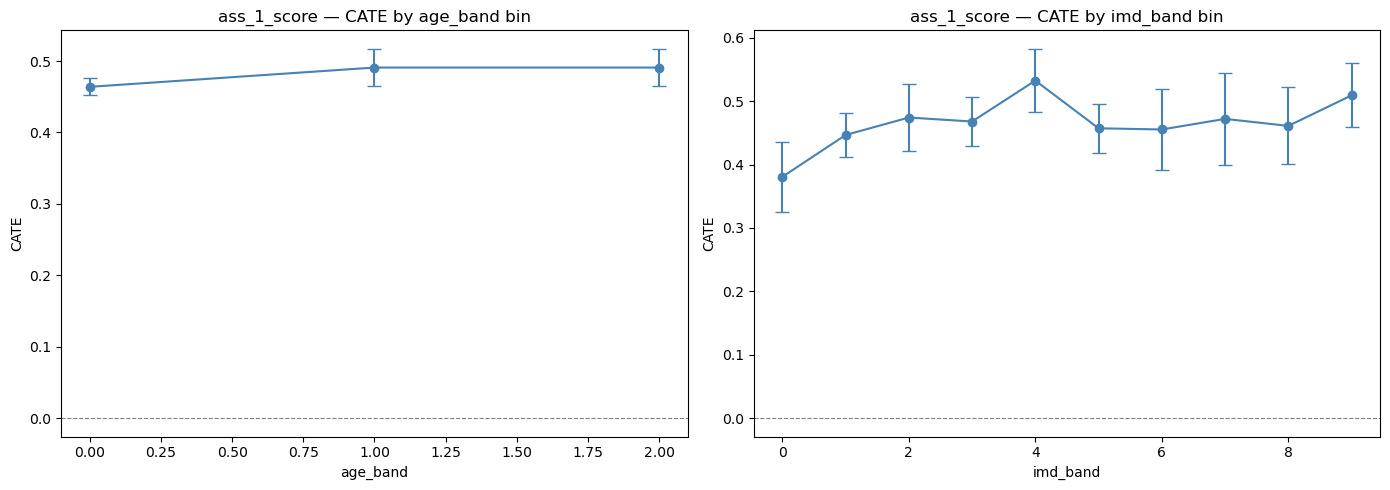

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_1_score.png


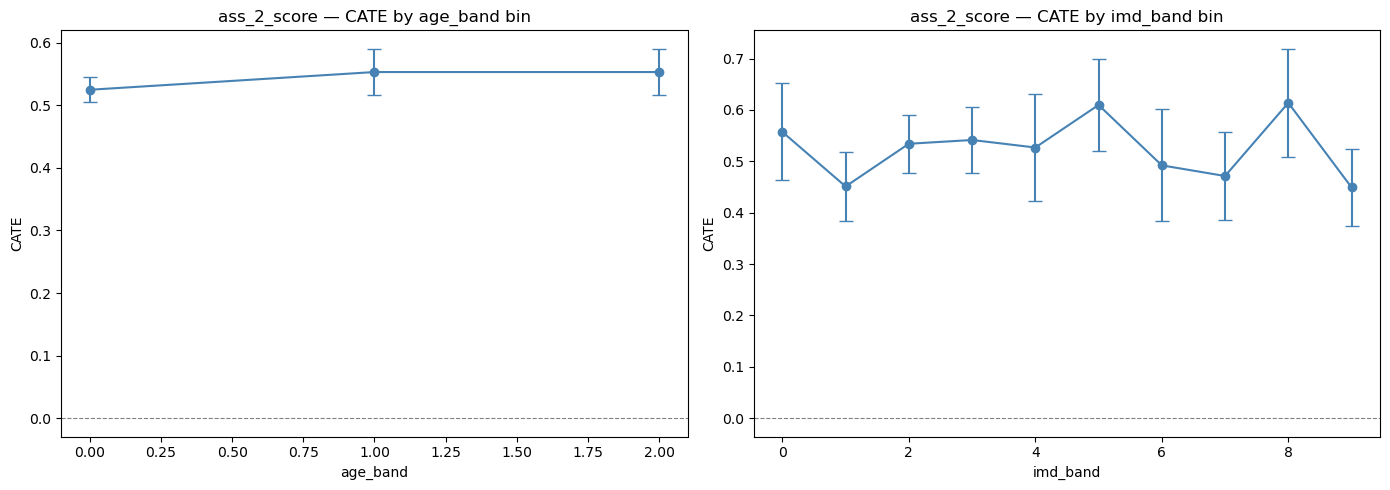

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_2_score.png


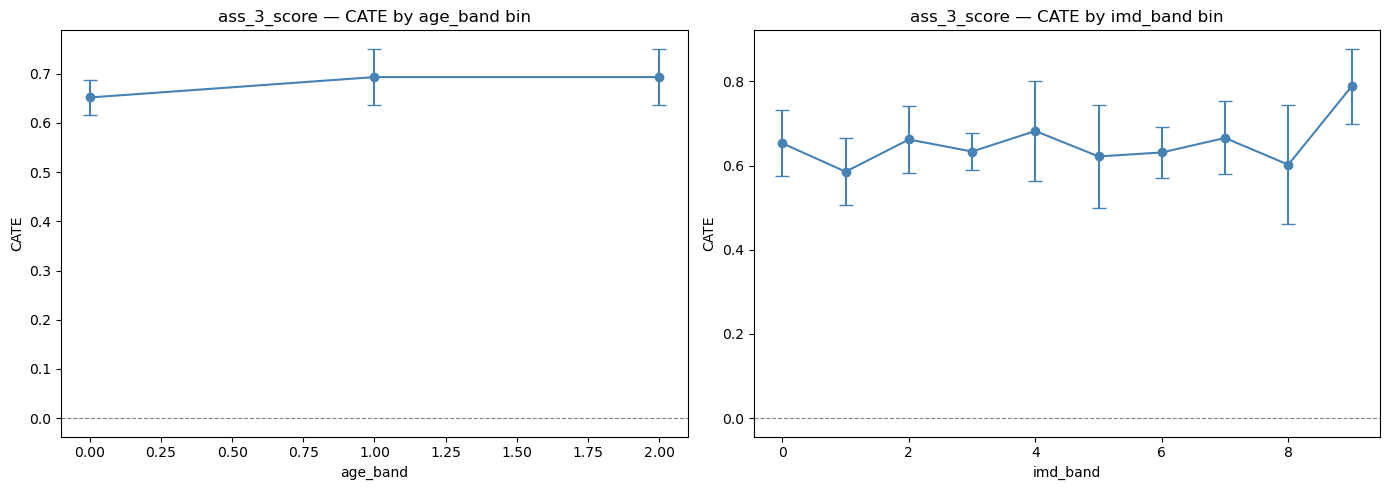

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_3_score.png


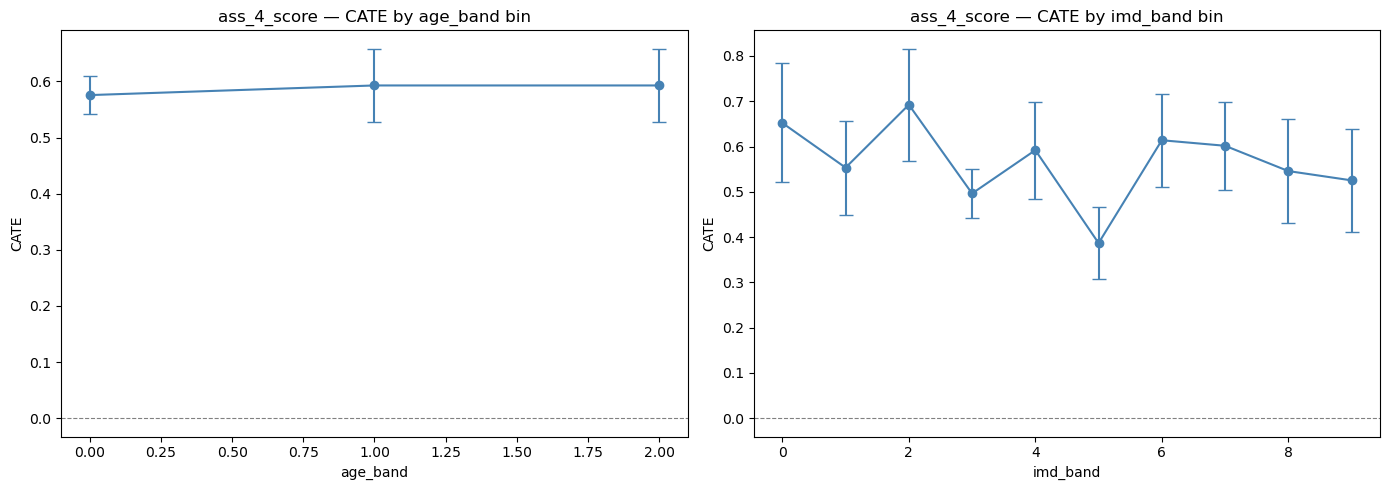

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_4_score.png


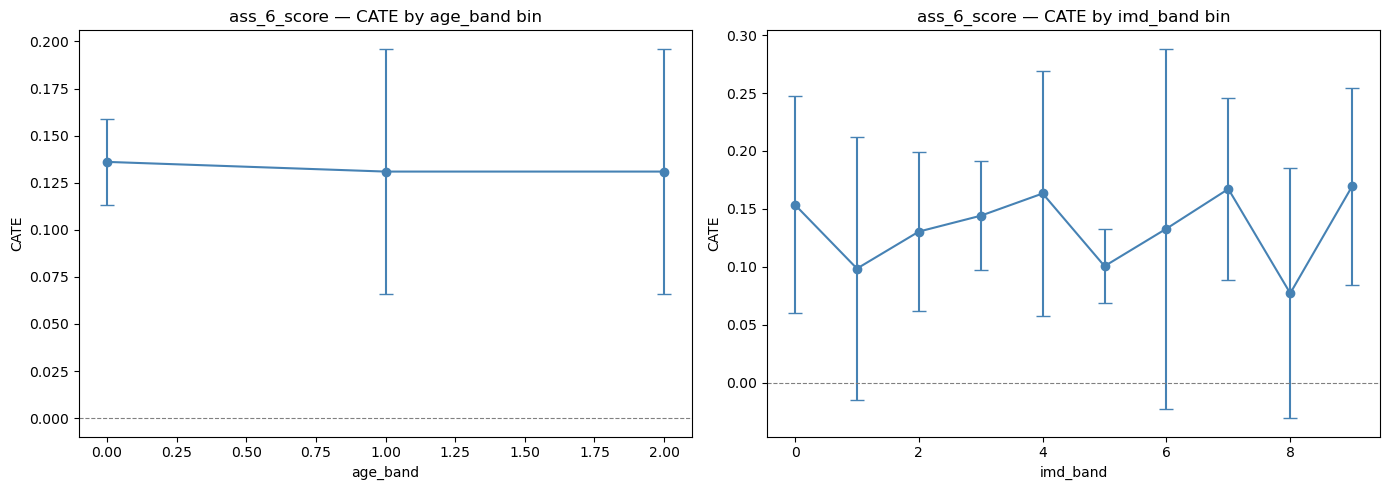

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_6_score.png


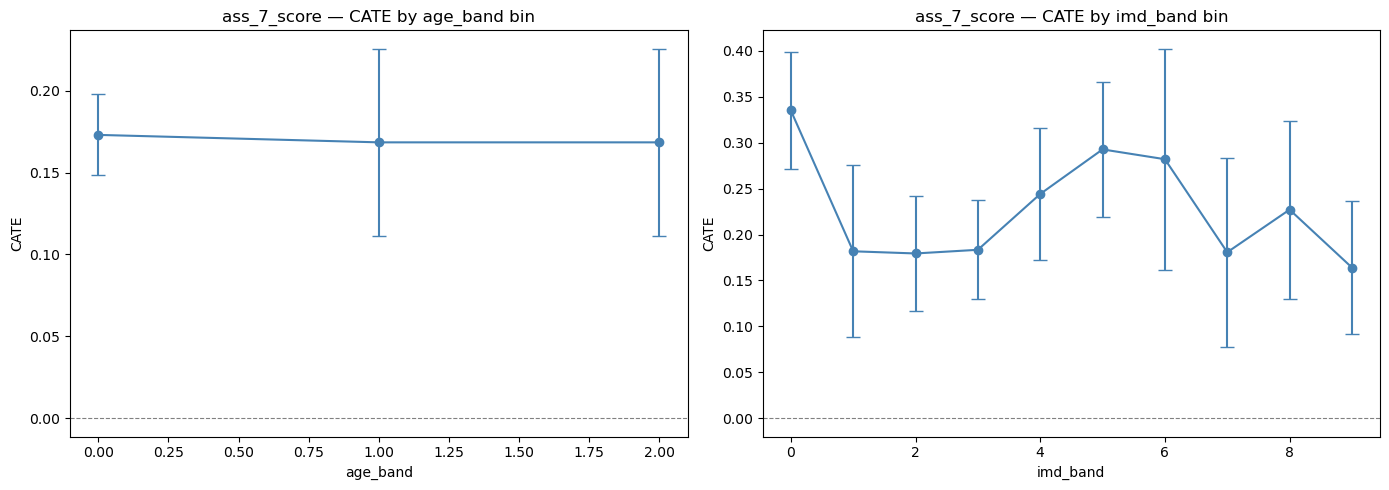

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_7_score.png


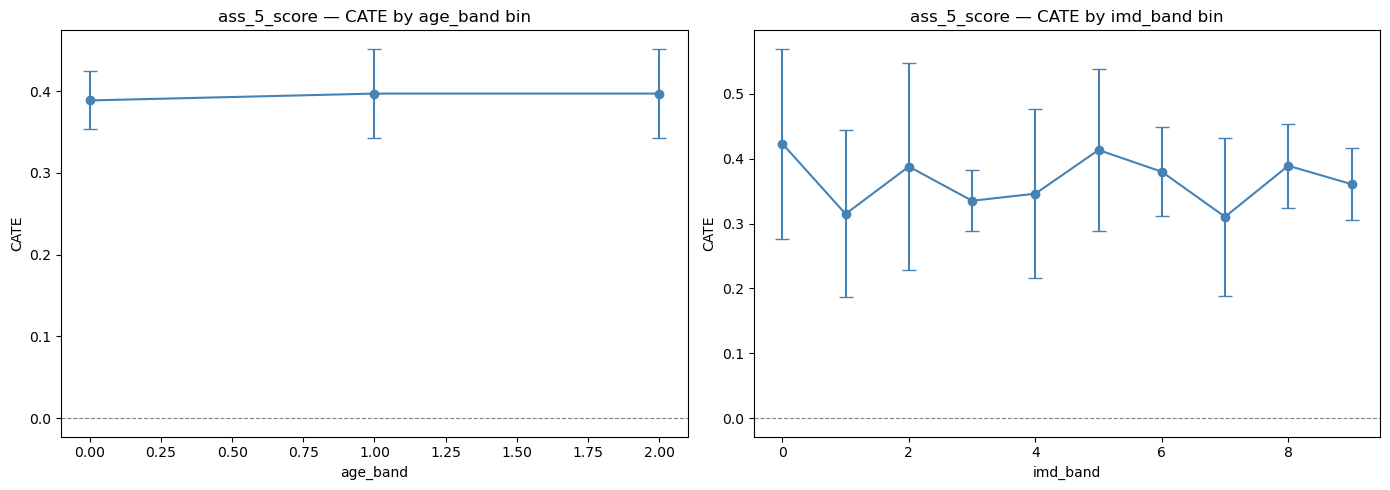

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_5_score.png


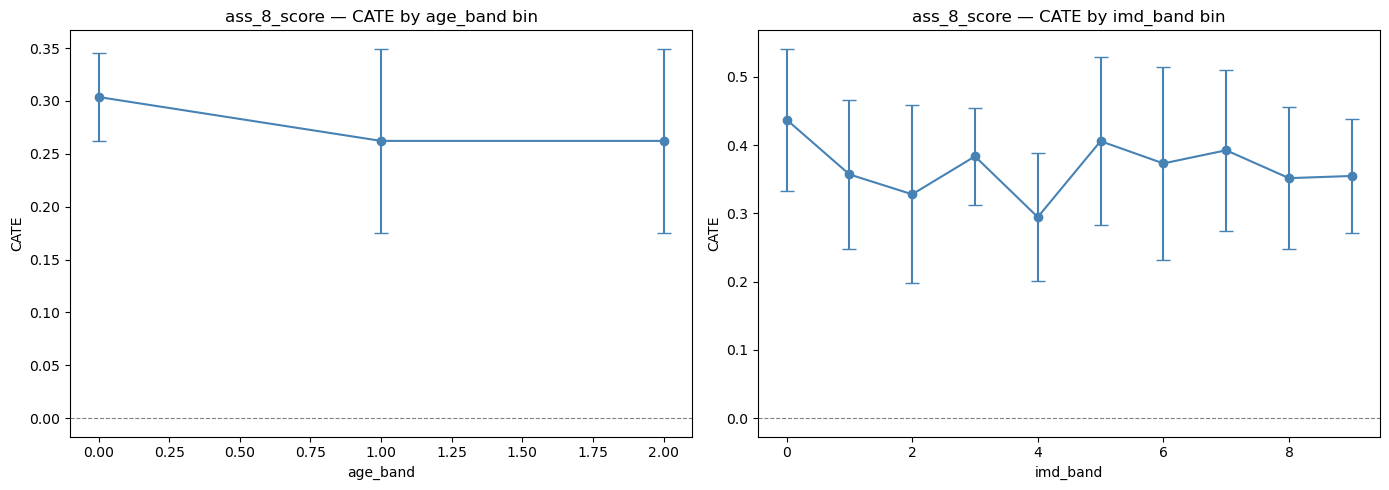

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_8_score.png


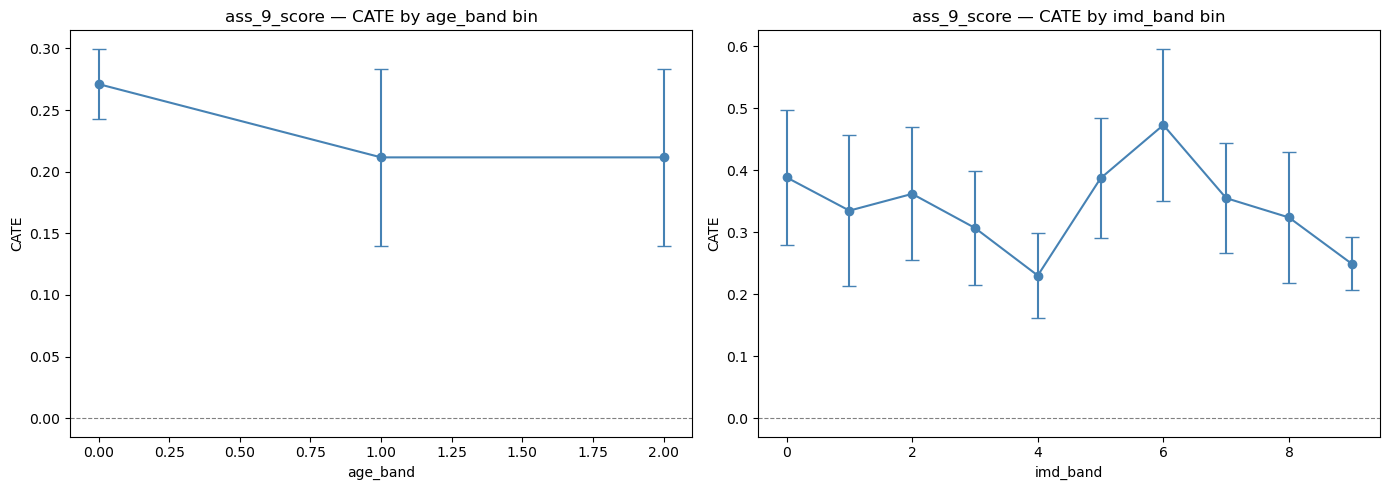

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_9_score.png


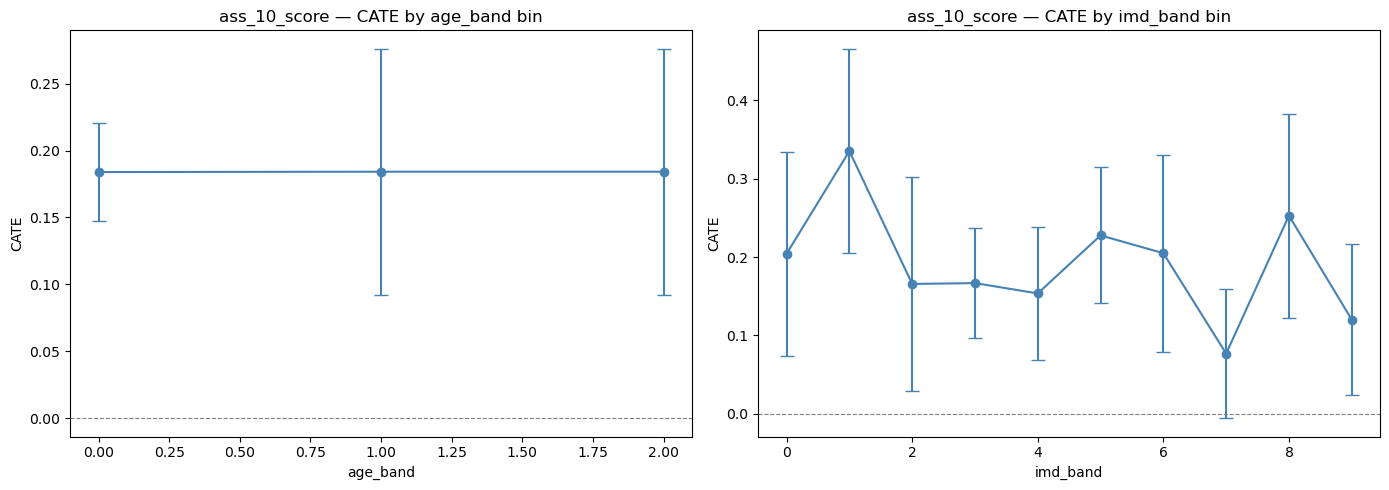

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_10_score.png


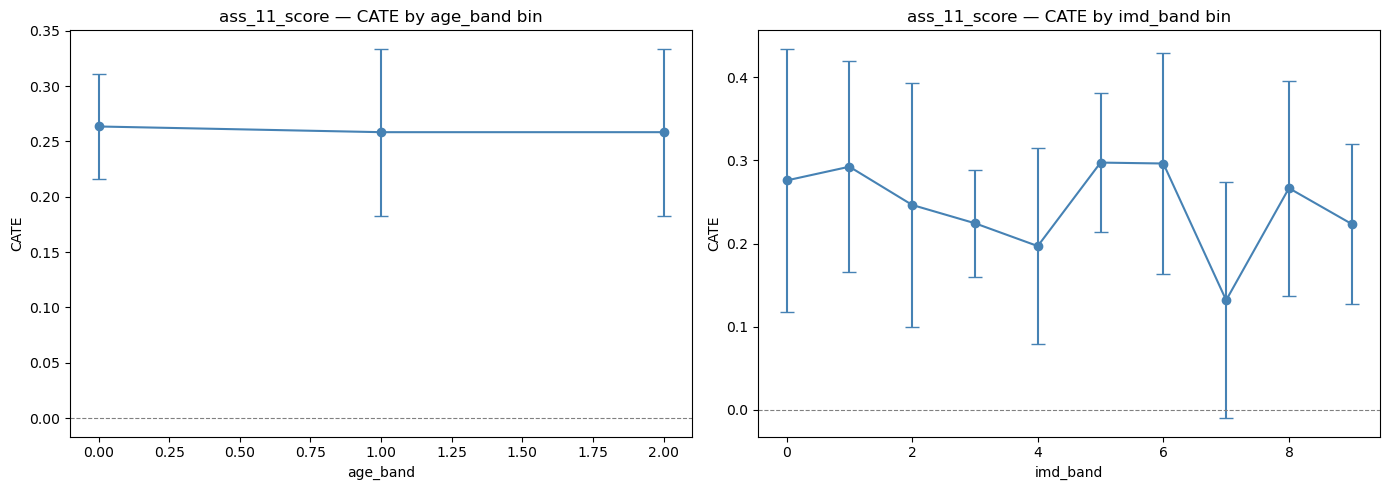

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_11_score.png


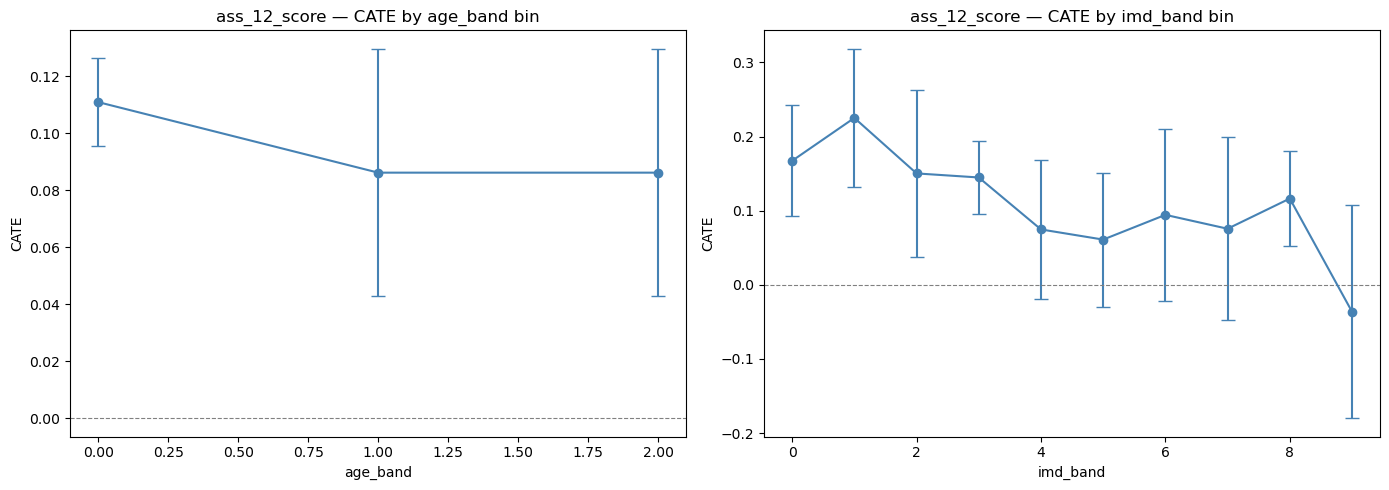

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG2_CATE_ass_12_score.png


In [37]:
# Block 10 — CATE point + CI plots for DAG2 treatments

for treatment in dag2_treatments:
    adj_set = dag2_adjustment_sets[treatment]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, moderator in zip(axes, moderators):
        W_cols = [c for c in adj_set if c != moderator]

        X = df_dag2_cate[[moderator]].values
        T = df_dag2_cate[treatment].values
        Y = df_dag2_cate['final_result'].values
        W = df_dag2_cate[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        bin_values = sorted(df_dag2_cate[moderator].unique())
        X_bins = np.array(bin_values).reshape(-1, 1)

        point_estimates = est.effect(X_bins)
        lb, ub = est.effect_interval(X_bins, alpha=0.05)
        yerr = np.array([point_estimates - lb, ub - point_estimates])

        ax.errorbar(bin_values, point_estimates, yerr=yerr, fmt='o-', capsize=5, color='steelblue')
        ax.set_xlabel(moderator)
        ax.set_ylabel('CATE')
        ax.set_title(f'{treatment} — CATE by {moderator} bin')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"FFF_DAG2_CATE_{treatment}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## 3-DAG-split ATE heatmap — all 32 treatments across DAG1/DAG2/DAG3

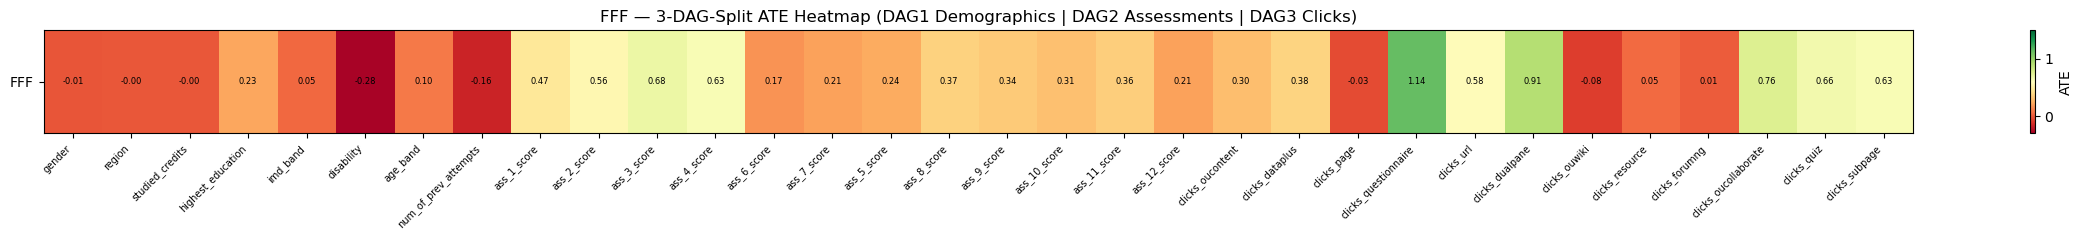

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_3DAGSplit_ATE_heatmap.png


In [40]:
# Block 11 — Combined ATE heatmap across DAG1+DAG2+DAG3

all_split_results = pd.concat([dag1_results_df, dag2_results_df, dag3_results_df], ignore_index=True)

heatmap_data = all_split_results.set_index('treatment')[['ATE']].T

plt.figure(figsize=(24, 2.5))
plt.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.3, vmax=1.5)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right', fontsize=7)
plt.yticks([0], ['FFF'])
plt.colorbar(label='ATE')

for i, val in enumerate(heatmap_data.values[0]):
    plt.text(i, 0, f'{val:.2f}', ha='center', va='center', fontsize=6)

plt.title('FFF — 3-DAG-Split ATE Heatmap (DAG1 Demographics | DAG2 Assessments | DAG3 Clicks)')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "FFF_3DAGSplit_ATE_heatmap.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")

## Three-panel DAG-with-ATE overlay — DAG1, DAG2, DAG3 side by side

WARNING — missing pos in DAG3 — Individual Clicks vs final_result: ['clicks_homepage']


KeyError: 'clicks_homepage'

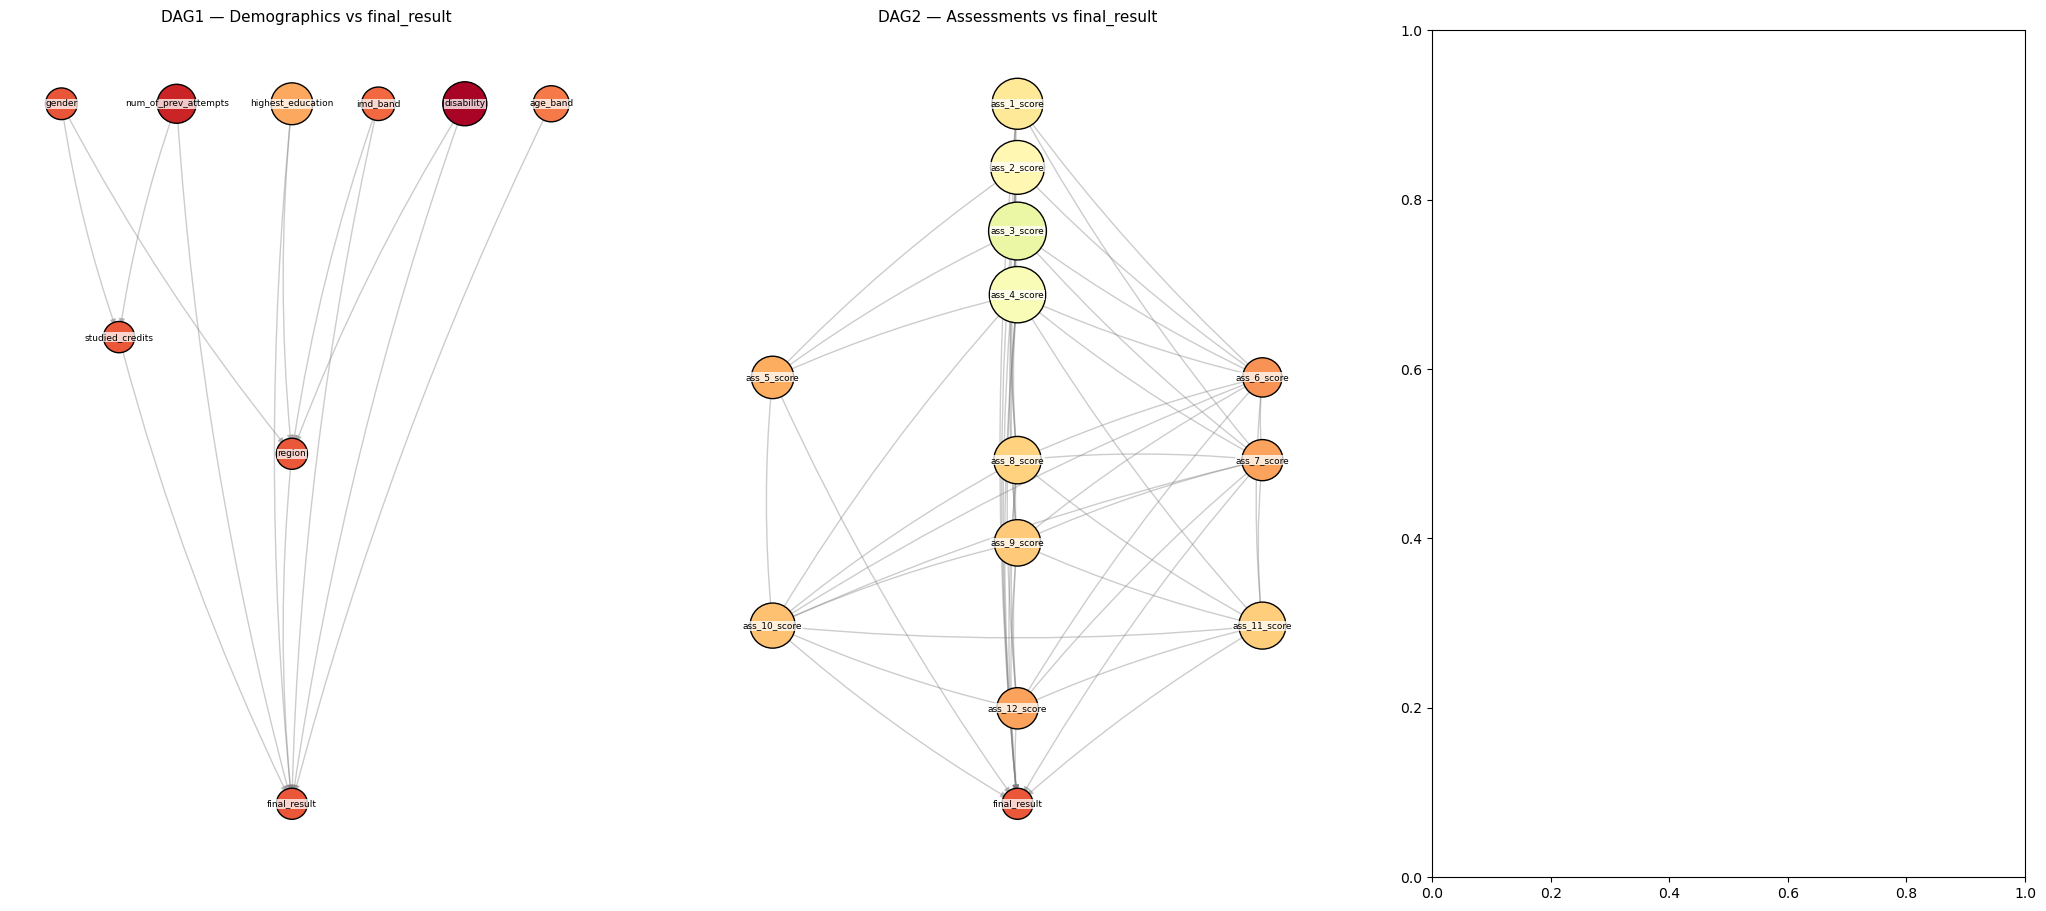

In [43]:
# Block 12 — Three-panel DAG-with-ATE overlay

pos1 = {
    'gender': (0, 4),
    'num_of_prev_attempts': (2, 4),
    'studied_credits': (1, 3),
    'highest_education': (4, 4),
    'imd_band': (5.5, 4),
    'disability': (7, 4),
    'age_band': (8.5, 4),
    'region': (4, 2.5),
    'final_result': (4, 1),
}

pos2 = {
    'ass_1_score': (5, 7),
    'ass_2_score': (5, 6),
    'ass_3_score': (5, 5),
    'ass_4_score': (5, 4),
    'ass_5_score': (2, 2.7),
    'ass_6_score': (8, 2.7),
    'ass_7_score': (8, 1.4),
    'ass_8_score': (5, 1.4),
    'ass_9_score': (5, 0.1),
    'ass_10_score': (2, -1.2),
    'ass_11_score': (8, -1.2),
    'ass_12_score': (5, -2.5),
    'final_result': (5, -4),
}

pos3 = {
    'clicks_questionnaire': (0, 5),
    'clicks_dualpane': (2, 5),
    'clicks_url': (4, 5),
    'clicks_page': (0, 3.5),
    'clicks_ouwiki': (2, 3.5),
    'clicks_oucollaborate': (4, 3.5),
    'clicks_oucontent': (1, 2),
    'clicks_forumng': (3, 2),
    'clicks_quiz': (5, 3.5),
    'clicks_subpage': (0, 0.5),
    'clicks_resource': (2, 0.5),
    'clicks_dataplus': (1, -1),
    'final_result': (2, -2.5),
}

ate_lookup_all = all_split_results.set_index('treatment')['ATE'].to_dict()

fig, axes = plt.subplots(1, 3, figsize=(26, 11))

dag_configs = [
    (G1, pos1, dag1_edges, axes[0], 'DAG1 — Demographics vs final_result'),
    (G2, pos2, dag2_edges, axes[1], 'DAG2 — Assessments vs final_result'),
    (G3, pos3, dag3_edges, axes[2], 'DAG3 — Individual Clicks vs final_result'),
]

for G_panel, pos_panel, edges_panel, ax, title in dag_configs:
    node_colors, node_sizes = [], []
    for node in G_panel.nodes():
        ate_val = ate_lookup_all.get(node, 0)
        node_colors.append(ate_val)
        node_sizes.append(500 + abs(ate_val) * 1800)

    missing_pos = [n for n in G_panel.nodes() if n not in pos_panel]
    if missing_pos:
        print(f"WARNING — missing pos in {title}:", missing_pos)

    nx.draw_networkx_edges(G_panel, pos_panel, ax=ax, edge_color='gray', arrows=True,
                            arrowsize=9, alpha=0.4, connectionstyle='arc3,rad=0.05')
    nc = nx.draw_networkx_nodes(G_panel, pos_panel, ax=ax, node_color=node_colors, node_size=node_sizes,
                                 cmap='RdYlGn', vmin=-0.3, vmax=1.5, edgecolors='black')
    nx.draw_networkx_labels(G_panel, pos_panel, ax=ax, font_size=6.5,
                             bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.3))
    ax.set_title(title, fontsize=11)
    ax.axis('off')

cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.02])
cbar = plt.colorbar(nc, cax=cbar_ax, orientation='horizontal')
cbar.set_label('ATE')

plt.suptitle('FFF — 3-DAG-Split, DAG-with-ATE Node Overlay', fontsize=14, y=1.02)
save_path = os.path.join(OUTPUT_DIR, "FFF_3DAGSplit_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {save_path}")

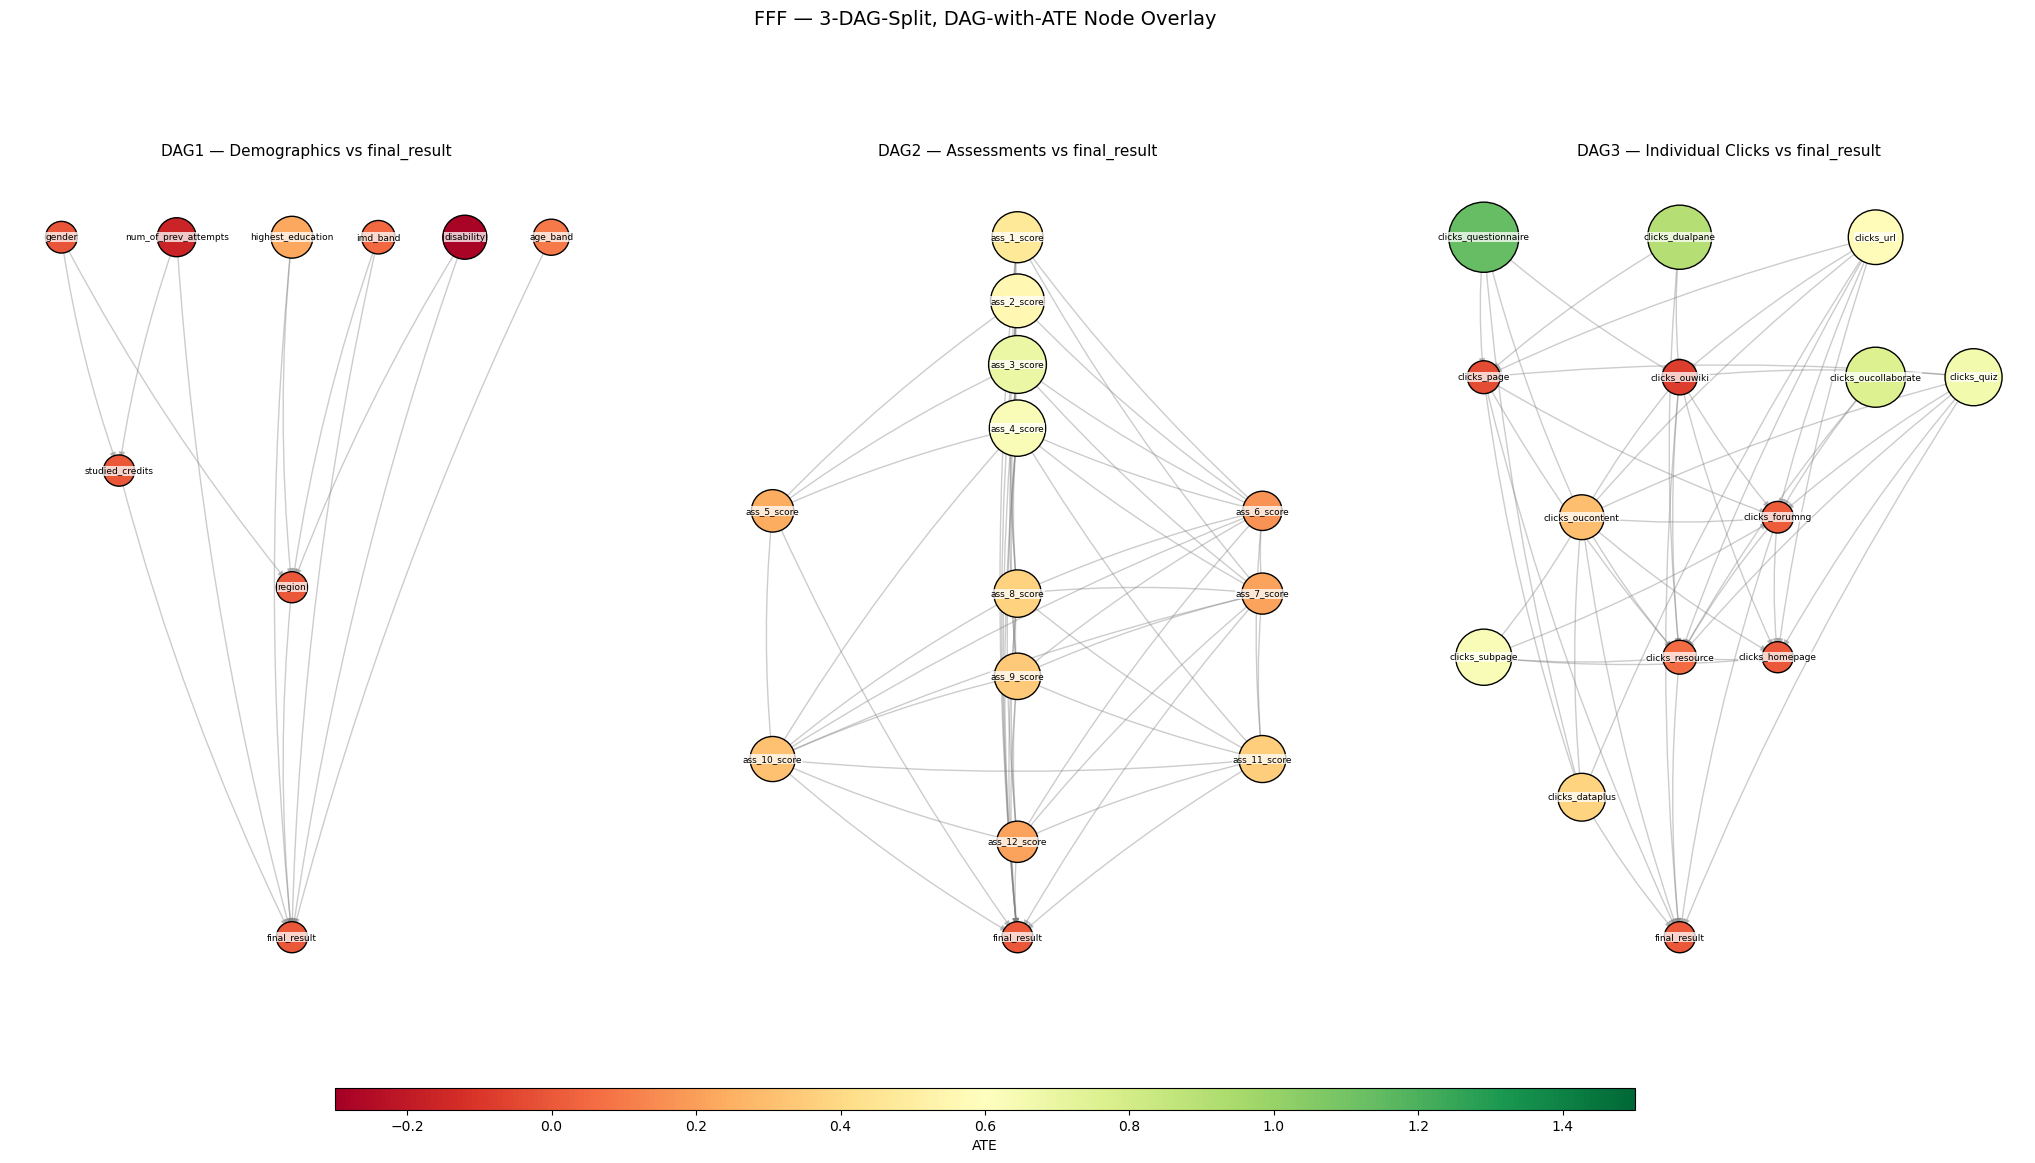

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_3DAGSplit_DAG_with_ATE.png


In [45]:
# Block 12 (corrected) — add missing clicks_homepage position

pos3['clicks_homepage'] = (3, 0.5)

fig, axes = plt.subplots(1, 3, figsize=(26, 11))

dag_configs = [
    (G1, pos1, dag1_edges, axes[0], 'DAG1 — Demographics vs final_result'),
    (G2, pos2, dag2_edges, axes[1], 'DAG2 — Assessments vs final_result'),
    (G3, pos3, dag3_edges, axes[2], 'DAG3 — Individual Clicks vs final_result'),
]

for G_panel, pos_panel, edges_panel, ax, title in dag_configs:
    node_colors, node_sizes = [], []
    for node in G_panel.nodes():
        ate_val = ate_lookup_all.get(node, 0)
        node_colors.append(ate_val)
        node_sizes.append(500 + abs(ate_val) * 1800)

    missing_pos = [n for n in G_panel.nodes() if n not in pos_panel]
    if missing_pos:
        print(f"WARNING — missing pos in {title}:", missing_pos)

    nx.draw_networkx_edges(G_panel, pos_panel, ax=ax, edge_color='gray', arrows=True,
                            arrowsize=9, alpha=0.4, connectionstyle='arc3,rad=0.05')
    nc = nx.draw_networkx_nodes(G_panel, pos_panel, ax=ax, node_color=node_colors, node_size=node_sizes,
                                 cmap='RdYlGn', vmin=-0.3, vmax=1.5, edgecolors='black')
    nx.draw_networkx_labels(G_panel, pos_panel, ax=ax, font_size=6.5,
                             bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.3))
    ax.set_title(title, fontsize=11)
    ax.axis('off')

cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.02])
cbar = plt.colorbar(nc, cax=cbar_ax, orientation='horizontal')
cbar.set_label('ATE')

plt.suptitle('FFF — 3-DAG-Split, DAG-with-ATE Node Overlay', fontsize=14, y=1.02)
save_path = os.path.join(OUTPUT_DIR, "FFF_3DAGSplit_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {save_path}")